# EDA for house prices

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.api as sm
# Ignoring all future warnings
warnings.filterwarnings('ignore', category = FutureWarning)

In [35]:
data = pd.read_csv("train.csv")
data.drop(columns = "Id", inplace = True)
data.sample(5)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1117,20,RL,57.0,9764,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,130000
1352,50,RM,50.0,6000,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,134900
882,60,RL,NaN,9636,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,MnPrv,NaN,0,12,2009,WD,Normal,178000
192,20,RL,68.0,9017,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,192000
162,20,RL,95.0,12182,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,New,Partial,220000


In [36]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

## Checking the distribution of the target

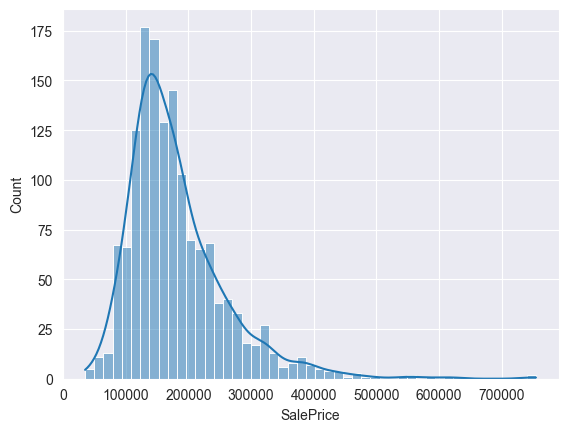

In [38]:
sns.histplot(x = "SalePrice", data = data, kde = True)
plt.show()

Seems like the feature is right skewed, suggesting expensive houses are less in number.

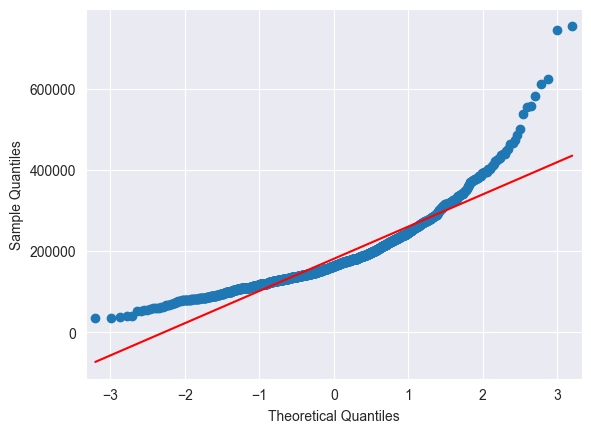

In [39]:
sm.qqplot(data["SalePrice"], line = "s", linewidth = 2)
plt.show()

Maybe log transform will help us. will do it later. So we have to **Log Transform the target** Later

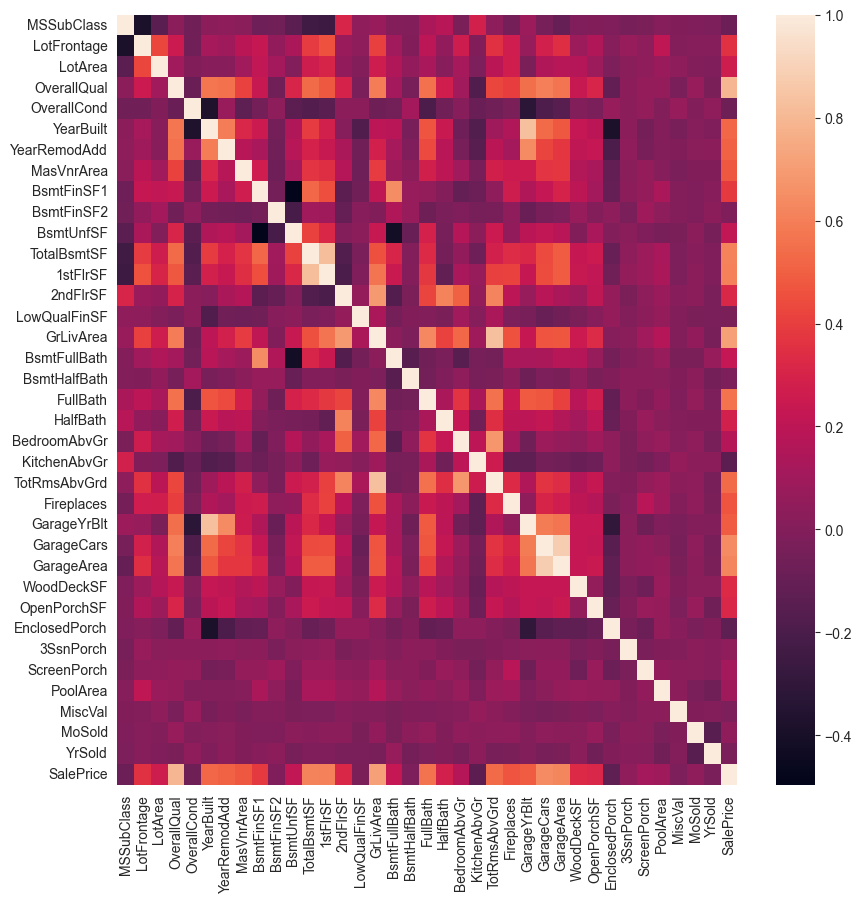

In [40]:
plt.figure(figsize=(10,10))
sns.heatmap(data.select_dtypes(exclude = "object").corr())
plt.show()

seems like features like GrLivArea, OverallQual, GarageCars, GarageArea, FullBath, etc are the features that affect it a lot.
Lets make a hypothesis.

**GrLiveArea affects the SalePrice and is predictive in predicting SalePrice.**

Now Lets test it!

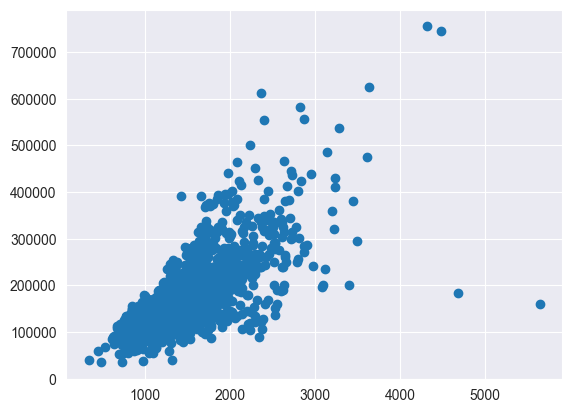

In [41]:
plt.scatter(data["GrLivArea"], data["SalePrice"])
plt.show()

uhmm.... lets look at the distribution a bit

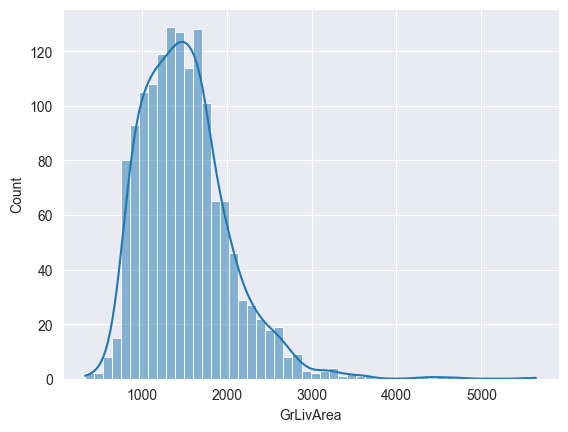

np.float64(1.3665603560164552)

In [42]:
sns.histplot(data["GrLivArea"], bins = 50, kde = True)
plt.show()
data["GrLivArea"].skew()

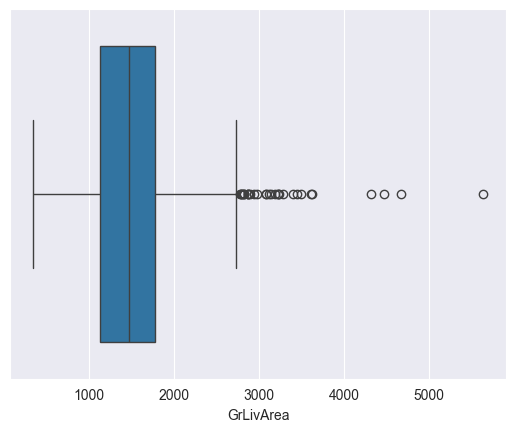

In [43]:
sns.boxplot(x = "GrLivArea", data = data)
plt.show()

seems like there is a skew and a bit of outliers. lets reduce it with a log transform magic. there are even huge houses with area around 3500-5700. these pretty much seem like huge houses the errors. also the data is concentrated in the middle.

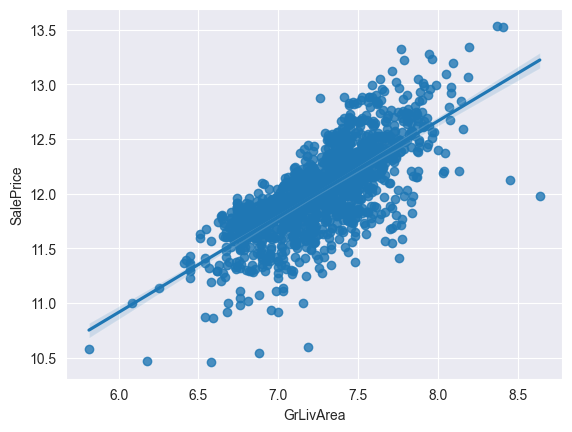

In [44]:
data[["GrLivArea","SalePrice"]] = np.log1p(data[["GrLivArea","SalePrice"]])
sns.regplot(x = "GrLivArea", y = "SalePrice", data = data)
plt.show()


Seems like it is indeed predective! just needed to use those log transforms
now lets check the outliers of this feature with a boxplot